# Exploratory Data Analysis (EDA) of Cardiovascular Disease Dataset

Author: Thimira Kalansooriya  
Task: Cardiovascular Dataset Exploratory Data Analysis  
Objective: Identify patterns and insights related to cardiovascular disease risk factors.

This analysis explores the relationships between patient health indicators such as age, blood pressure, cholesterol, and lifestyle habits with the presence of cardiovascular disease.

## 1. Import Required Libraries

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# display settings
pd.set_option("display.max_columns", None)

## 2. Load Dataset

In [24]:
df = pd.read_csv("E:/Cardio_EDA_Analysis/Cardio_EDA_Analysis/cardio-eda-analysis/data/cardio_train.csv", sep=",")

df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


## 3. Dataset Overview

Understanding dataset structure including:
- number of rows
- number of columns
- feature types

In [25]:
df.shape

(70000, 13)

In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


In [27]:
df.describe()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,28851.302323,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,0.000000,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,25006.750000,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,50001.500000,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,74889.250000,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


## 4. Missing Value Analysis

In [29]:
df.isnull().sum()

id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

## 5. Duplicate Records



df.duplicated().sum()




df = df.drop_duplicates()

## 6. Drop Irrelevant Columns

In [30]:
df = df.drop("id", axis=1)
df.head()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,17474,1,156,56.0,100,60,1,1,0,0,0,0


## 7. Feature Engineering

In [31]:
df["age_years"] = (df["age"] / 365).astype(int)

df[["age", "age_years"]].head()

,age,age_years
0,18393,50
1,20228,55
2,18857,51
3,17623,48
4,17474,47


### Calculate BMI

In [33]:
df["height_m"] = df["height"] / 100
df["BMI"] = df["weight"] / (df["height_m"] ** 2)

df[["weight", "height", "BMI"]].head()

,weight,height,BMI
0,62.0,168,21.967120
1,85.0,156,34.927679
2,64.0,165,23.507805
3,82.0,169,28.710479
4,56.0,156,23.011177


## 8. Outlier Detection

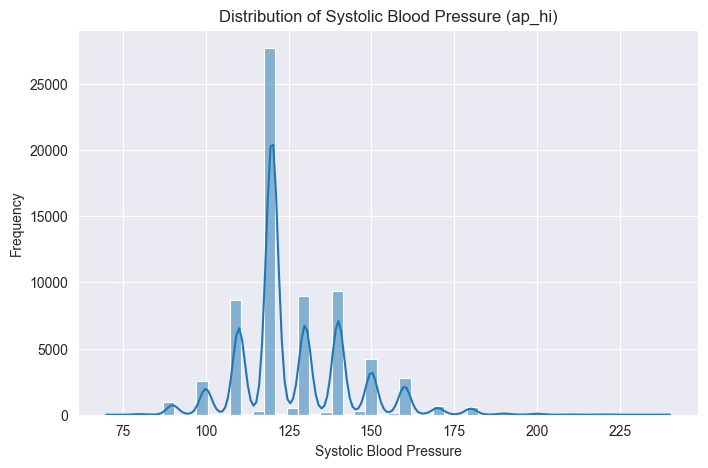

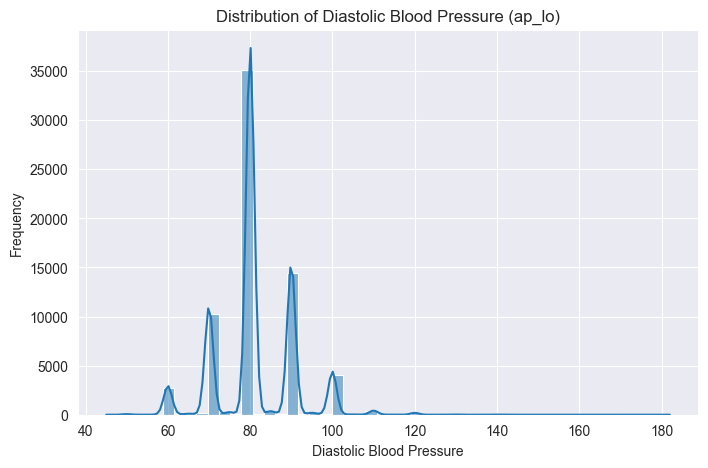

In [52]:
plt.figure(figsize=(8,5))
sns.histplot(df["ap_hi"], bins=50, kde=True)
plt.title("Distribution of Systolic Blood Pressure (ap_hi)")
plt.xlabel("Systolic Blood Pressure")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(df["ap_lo"], bins=50, kde=True)
plt.title("Distribution of Diastolic Blood Pressure (ap_lo)")
plt.xlabel("Diastolic Blood Pressure")
plt.ylabel("Frequency")
plt.show()

## 9. Remove Unrealistic Values

In [53]:
df = df[(df['ap_hi'] > 60) & (df['ap_hi'] < 250)]
df = df[(df['ap_lo'] > 40) & (df['ap_lo'] < 200)]
df = df[df['ap_hi'] > df['ap_lo']]

## 10. Univariate Analysis

### Age Distribution

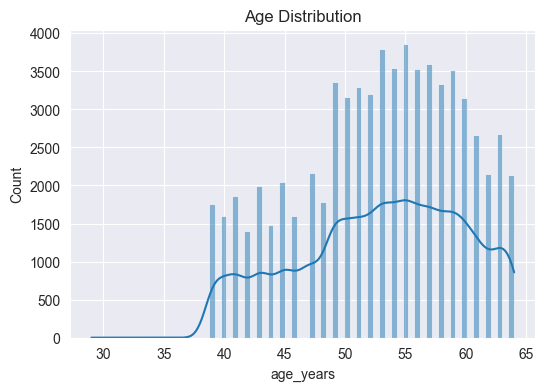

In [38]:
plt.figure(figsize=(6,4))
sns.histplot(df["age_years"], kde=True)
plt.title("Age Distribution")
plt.show()

### BMI Distribution

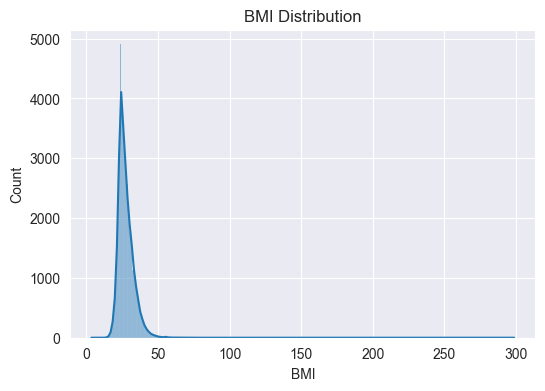

In [39]:
plt.figure(figsize=(6,4))
sns.histplot(df["BMI"], kde=True)
plt.title("BMI Distribution")
plt.show()

## 11. Cardiovascular Disease Distribution

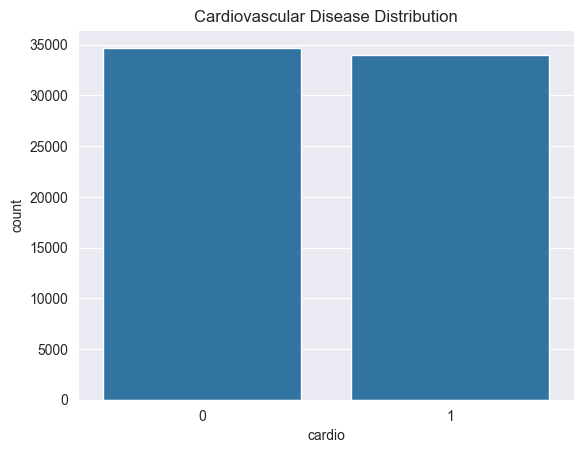

In [40]:
sns.countplot(x="cardio", data=df)
plt.title("Cardiovascular Disease Distribution")
plt.show()

## 12. Categorical Feature Analysis

### Cholesterol

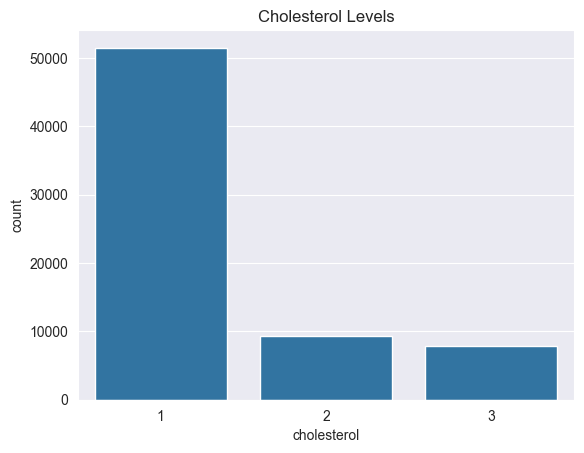

In [41]:
sns.countplot(x="cholesterol", data=df)
plt.title("Cholesterol Levels")
plt.show()

### Smoking

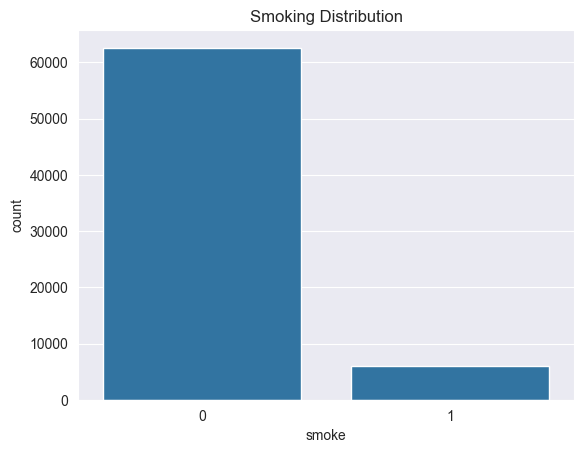

In [42]:
sns.countplot(x="smoke", data=df)
plt.title("Smoking Distribution")
plt.show()

## 13. Correlation Matrix

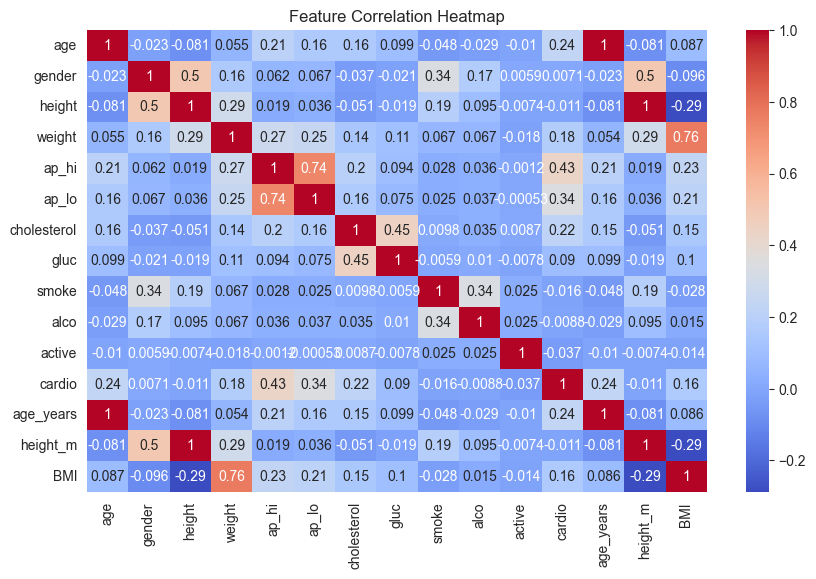

In [43]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

## 14. Relationship Between Features and Cardiovascular Disease

### Age vs Cardio

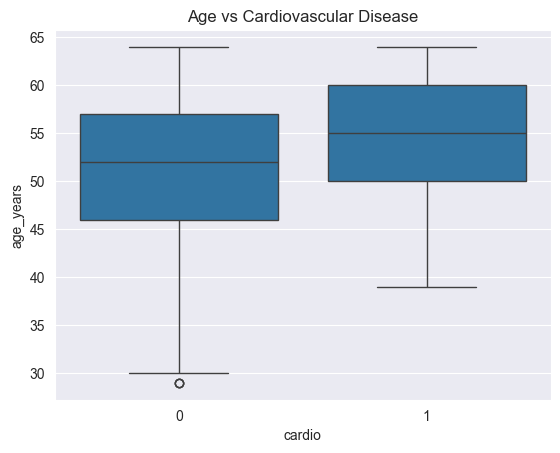

In [44]:
sns.boxplot(x="cardio", y="age_years", data=df)
plt.title("Age vs Cardiovascular Disease")
plt.show()

### Blood Pressure vs Cardio

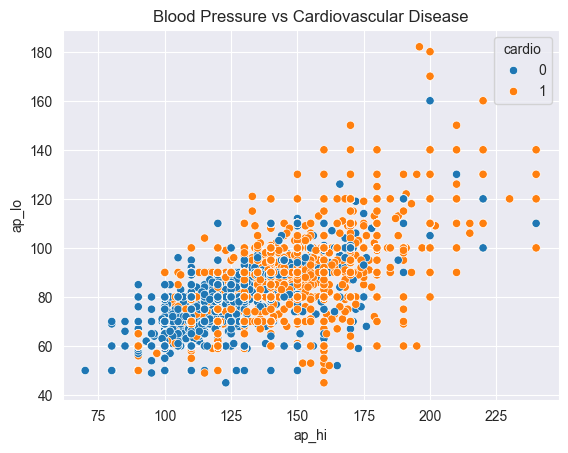

In [45]:
sns.scatterplot(x="ap_hi", y="ap_lo", hue="cardio", data=df)
plt.title("Blood Pressure vs Cardiovascular Disease")
plt.show()

## 15. Key Insights

1. Age shows a positive relationship with cardiovascular disease risk.
2. Higher systolic and diastolic blood pressure values are associated with higher disease occurrence.
3. Cholesterol levels appear to correlate with cardiovascular disease.
4. BMI may indicate obesity-related cardiovascular risk.
5. Lifestyle factors such as smoking and alcohol consumption show weaker correlations compared to physiological factors.

In [57]:
df.to_csv("cardio_cleaned.csv", index=False)